# Análisis Descriptivo y Modelado — Sector Gastronómico Peruano
### Databricks · Spark SQL · **MLlib (PySpark)** · Folium
> **Refactorización Big Data:** Todo el ML corre distribuido con **Spark MLlib**.  
> Se elimina el cuello de botella de `.toPandas()` en los conjuntos de >1.2 M registros.  
> KMeans, TF-IDF y LDA corren sobre el cluster completo sin bajar datos al driver.

**Prerequisito:** Ejecutar primero `Medallon_Final_Corregido.ipynb`.


## 0 · Imports y configuración

In [0]:
# Geo y visualización (estas librerías sí son driver-only - sólo reciben agregados pequeños)
%pip install folium geopandas --quiet


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()


In [0]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import DoubleType, ArrayType, StringType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (VectorAssembler,StandardScaler,Tokenizer,StopWordsRemover,CountVectorizer,IDF,)
from pyspark.ml.clustering import KMeans, LDA
from pyspark.ml.evaluation import ClusteringEvaluator

# Visualización (driver-only, sobre agregados pequeños)
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
spark = SparkSession.builder.getOrCreate()

CATALOGO= 'proyecto_bda'
SCHEMA= 'bda_schema'
TBL_GOLD_FINAL= f'{CATALOGO}.{SCHEMA}.gold_reviews_final'
TBL_GOLD_STATS_CAT= f'{CATALOGO}.{SCHEMA}.gold_stats_categoria'
TBL_GOLD_FEAT_USUARIO = f'{CATALOGO}.{SCHEMA}.gold_features_usuario'
VOLUMEN_BASE = f'/Volumes/{CATALOGO}/{SCHEMA}/bda_volumen'
GEOJSON_DEP = f'{VOLUMEN_BASE}/peru_departamental_simple.geojson'
GEOJSON_PROV = f'{VOLUMEN_BASE}/peru_provincial_simple.geojson'
GEOJSON_DIST = f'{VOLUMEN_BASE}/peru_distrital_simple.geojson'

spark.sql(f'USE CATALOG {CATALOGO}')
spark.sql(f'USE SCHEMA {SCHEMA}')
print("OK")


OK


## 1)Carga de datos desde la capa Gold

In [0]:
df = spark.table(TBL_GOLD_FINAL)
df.createOrReplaceTempView('gold')

print(f'Registros en Gold : {df.count():,}')
print(f'Columnas: {df.columns}')
df.printSchema()


Registros en Gold : 1,294,709
Columnas: ['place_id', 'id_review', 'caption', 'relative_date', 'review_date', 'retrieval_date', 'rating', 'username', 'n_review_user', 'n_photo_user', 'url_user', 'url_source', 'text_len', 'word_count', 'caption_clean', 'rating_category', 'year', 'month', 'day_of_week', 'name', 'category', 'address', 'phoneNumber', 'coor', 'avg_rating', 'url', 'url_place', 'latitude', 'longitude', 'sentimiento']
root
 |-- place_id: string (nullable = true)
 |-- id_review: string (nullable = true)
 |-- caption: string (nullable = true)
 |-- relative_date: string (nullable = true)
 |-- review_date: timestamp (nullable = true)
 |-- retrieval_date: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- username: string (nullable = true)
 |-- n_review_user: string (nullable = true)
 |-- n_photo_user: string (nullable = true)
 |-- url_user: string (nullable = true)
 |-- url_source: string (nullable = true)
 |-- text_len: integer (nullable = true)
 |-- word_count: i

## 2)Análisis de Engagement Temporal

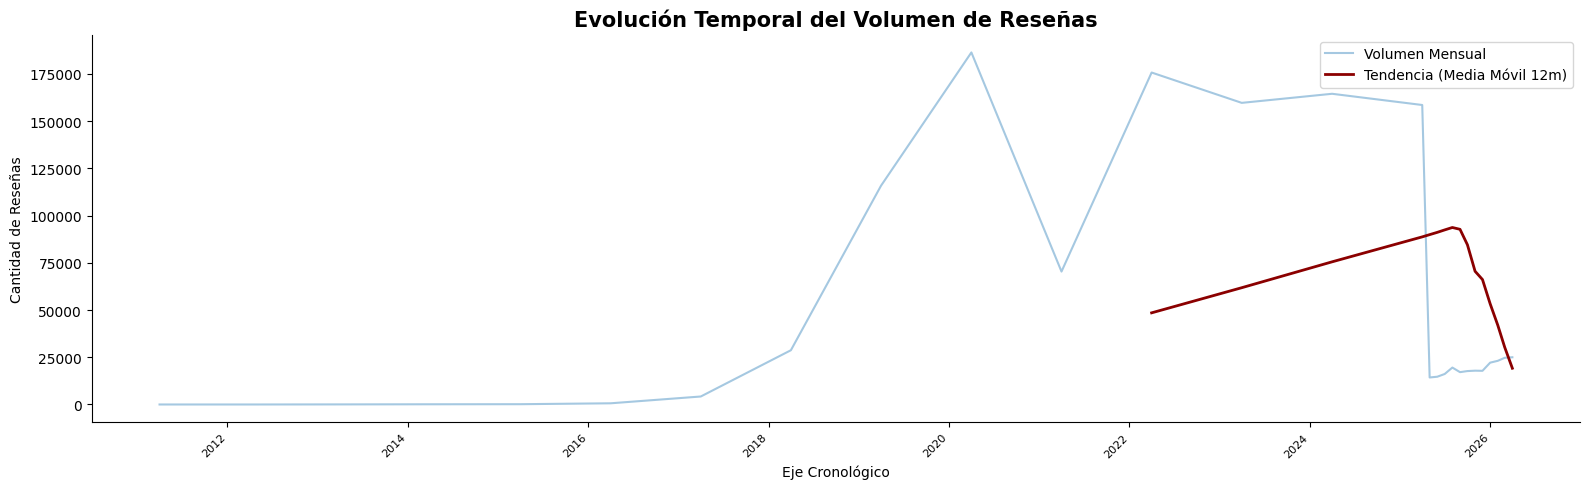

In [0]:
# Volumen mensual (solo se usa pandas para mostrar)
temporal = spark.sql("""
    SELECT
        DATE_FORMAT(review_date, 'yyyy-MM') AS anio_mes,
        COUNT(*) AS total_reviews
    FROM gold
    WHERE review_date IS NOT NULL
    GROUP BY anio_mes
    ORDER BY anio_mes
""").toPandas()

temporal['year_month_dt'] = pd.to_datetime(temporal['anio_mes'])
temporal['rolling_avg']   = temporal['total_reviews'].rolling(window=12).mean()

plt.figure(figsize=(16, 5))
sns.lineplot(data=temporal, x='year_month_dt', y='total_reviews', alpha=0.4, label='Volumen Mensual')
sns.lineplot(data=temporal, x='year_month_dt', y='rolling_avg',color='darkred', linewidth=2, label='Tendencia (Media Móvil 12m)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Evolución Temporal del Volumen de Reseñas', fontsize=15, fontweight='bold')
plt.xlabel('Eje Cronológico'); plt.ylabel('Cantidad de Reseñas')
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

/home/spark-d23ff1cf-dd1c-4185-b304-ce/.ipykernel/23338/command-5707122455738390-3894624048:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=day_dist, x='dia', y='total', palette='Blues_d')


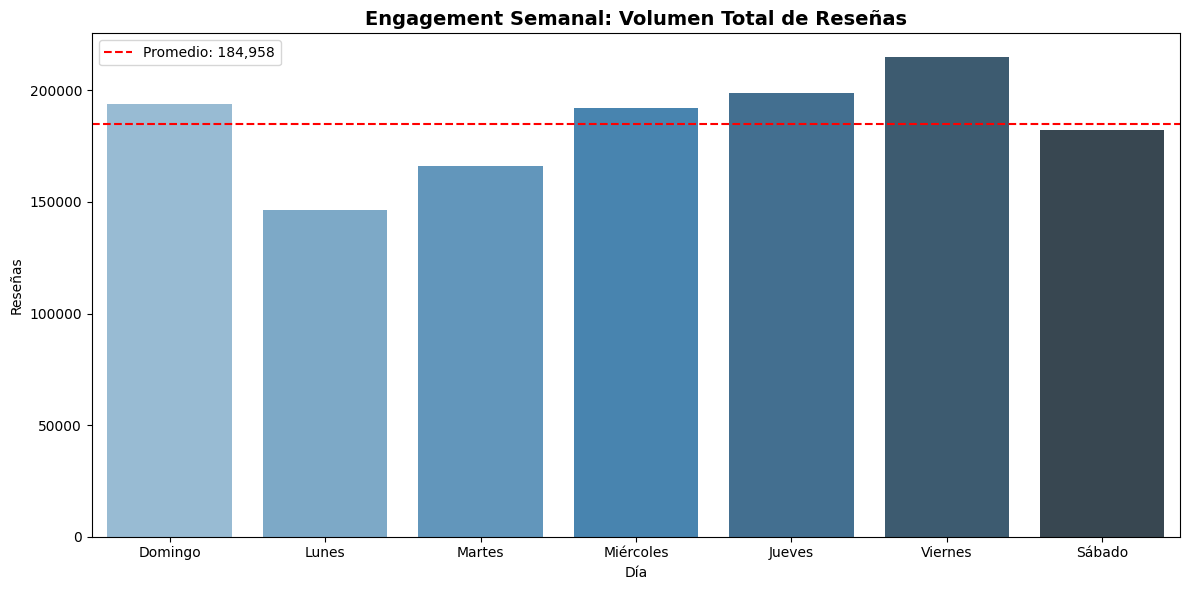

In [0]:
# Distribución por día de la semana
day_map = {1:'Domingo', 2:'Lunes', 3:'Martes', 4:'Miércoles', 5:'Jueves', 6:'Viernes', 7:'Sábado'}

day_dist = spark.sql("""
    SELECT day_of_week, COUNT(*) AS total
    FROM gold
    GROUP BY day_of_week
    ORDER BY day_of_week
""").toPandas()
day_dist['dia'] = day_dist['day_of_week'].map(day_map)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=day_dist, x='dia', y='total', palette='Blues_d')
if ax.get_legend(): ax.get_legend().remove()
plt.axhline(day_dist['total'].mean(), color='red', linestyle='--',label=f'Promedio: {int(day_dist["total"].mean()):,}')
plt.title('Engagement Semanal: Volumen Total de Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Día'); plt.ylabel('Reseñas'); plt.legend(); plt.tight_layout(); plt.show()

## 3)Análisis Geográfico Regional
Spark SQL agrega coordenadas. Se generan mapas con GeoPandas (departamento, provincia, Lima distrital).


In [0]:
# Agregación via spark solo se usa pandas para vista
geo_agg = spark.sql("""
    SELECT
        place_id, name, category, latitude, longitude,
        COUNT(id_review) AS total_reviews,
        ROUND(AVG(rating), 2) AS avg_rating
    FROM gold
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
    GROUP BY place_id, name, category, latitude, longitude
""").toPandas()

print(f'Locales con coordenadas: {len(geo_agg):,}')


Locales con coordenadas: 18,360


In [0]:
# GeoDataFrame - el join geo se hace en el driver sólo sobre el agregado de locales (gpd.sjoin es una operación de GeoPandas que no existe en Spark)
df_geo = spark.sql("""
    SELECT
        place_id,
        latitude,
        longitude,
        COUNT(*)              AS total_reviews,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(AVG(word_count), 2) AS avg_word_count
    FROM gold
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
    GROUP BY place_id, latitude, longitude
""").toPandas()

try:
    peru_dep  = gpd.read_file(GEOJSON_DEP)
    peru_prov = gpd.read_file(GEOJSON_PROV)
    peru_dist = gpd.read_file(GEOJSON_DIST)

    gdf_reviews = gpd.GeoDataFrame(df_geo,geometry=gpd.points_from_xy(df_geo.longitude, df_geo.latitude),crs='EPSG:4326') #sobre unicos
    gdf_dep = gpd.sjoin(gdf_reviews, peru_dep[['NOMBDEP', 'geometry']], predicate='within')
    print(f'GeoDataFrame listo: {len(gdf_dep):,} reseñas geolocalizadas')
except FileNotFoundError as e:
    print(f'GeoJSON no encontrado en el volumen: {e}')

GeoDataFrame listo: 17,755 reseñas geolocalizadas


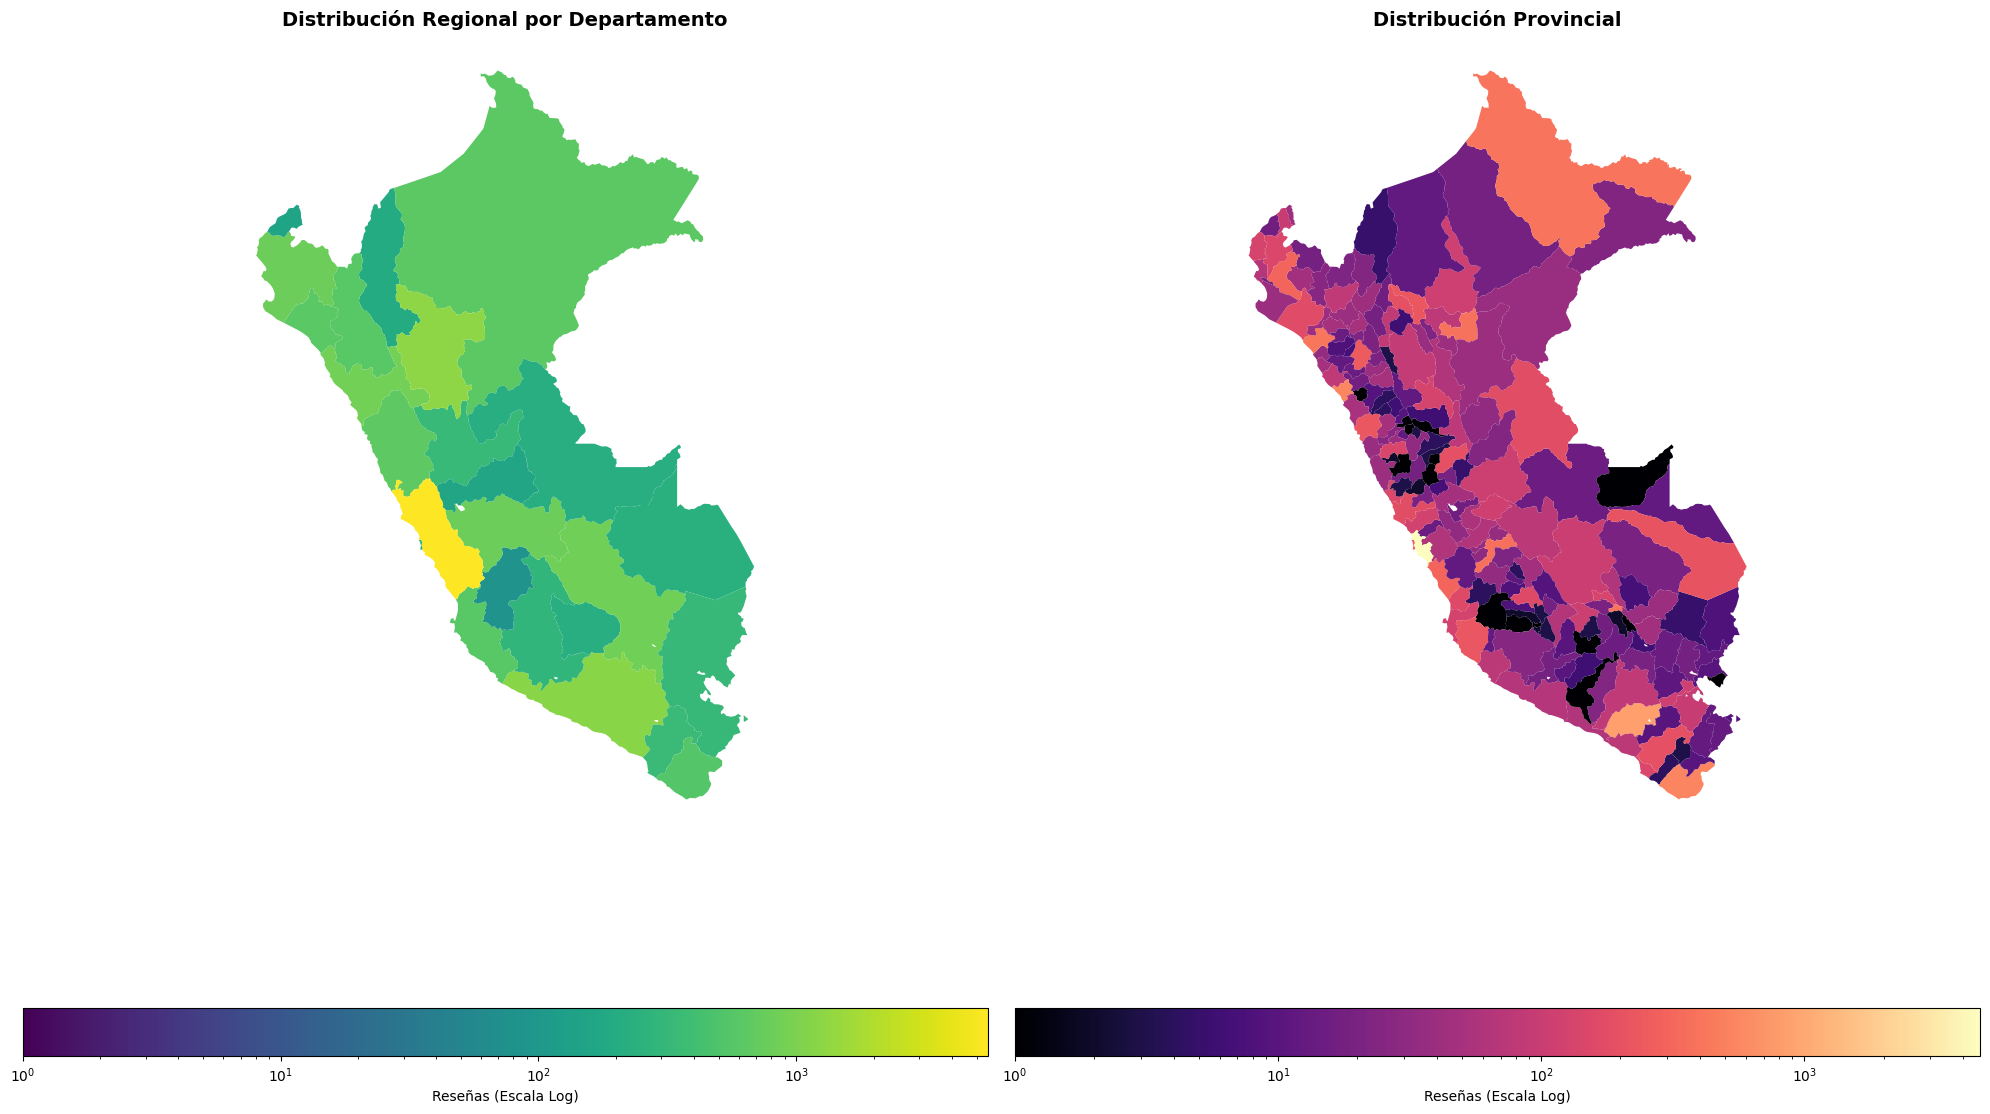

In [0]:
# Mapas coropléticos - Departamento y Provincia
try:
    dep_counts = gdf_dep.groupby('NOMBDEP').size().reset_index(name='review_count')
    dep_map    = peru_dep.merge(dep_counts, on='NOMBDEP', how='left').fillna({'review_count': 1})

    gdf_prov    = gpd.sjoin(gdf_reviews, peru_prov[['NOMBPROV', 'geometry']], predicate='within')
    prov_counts = gdf_prov.groupby('NOMBPROV').size().reset_index(name='review_count')
    prov_map    = peru_prov.merge(prov_counts, on='NOMBPROV', how='left').fillna({'review_count': 1})

    fig, ax = plt.subplots(1, 2, figsize=(20, 12))

    dep_map.plot(column='review_count', ax=ax[0], legend=True, cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=dep_map['review_count'].max()),
                 legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[0].set_title('Distribución Regional por Departamento', fontsize=14, fontweight='bold')
    ax[0].axis('off')

    prov_map.plot(column='review_count', ax=ax[1], legend=True, cmap='magma',
                  norm=colors.LogNorm(vmin=1, vmax=prov_map['review_count'].max()),
                  legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[1].set_title('Distribución Provincial', fontsize=14, fontweight='bold')
    ax[1].axis('off')

    plt.tight_layout(); plt.show()
except NameError:
    print('Falta carga de GeoDataFrame')

## 4 · Análisis por Categoría de Restaurante

In [0]:
display(spark.table(TBL_GOLD_STATS_CAT).orderBy(F.desc('total_resenas')).limit(9))


category,total_resenas,rating_promedio,rating_desviacion,resenas_positivas,resenas_negativas,promedio_palabras,total_locales,porcentaje_aprobacion
Restaurante,669389,4.12,1.2,515271,74654,7.7,8370,76.98
Restaurante peruano,92924,4.23,1.16,74496,9136,9.4,792,80.17
Pizzería,83091,4.23,1.16,66778,8024,7.9,1094,80.37
Cafetería,56487,4.34,1.08,47344,4512,10.2,830,83.81
Restaurante especializado en pollo,47412,4.06,1.25,35713,5968,7.3,647,75.32
Restaurante de comida rápida,44694,4.08,1.26,33943,5622,6.9,1018,75.95
Restaurante chino,43510,3.97,1.25,31496,5822,7.1,419,72.39
Panadería,33075,4.21,1.13,26245,2961,7.0,940,79.35
Heladería,29865,4.37,1.07,25178,2251,8.0,801,84.31


/home/spark-d23ff1cf-dd1c-4185-b304-ce/.ipykernel/23338/command-5707122455738397-2186603008:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.barplot(data=stats_pd, y='category', x='rating_promedio', palette='RdYlGn', ax=axes[0])
/home/spark-d23ff1cf-dd1c-4185-b304-ce/.ipykernel/23338/command-5707122455738397-2186603008:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=stats_pd, y='category', x='porcentaje_aprobacion', palette='Blues_d', ax=axes[1])


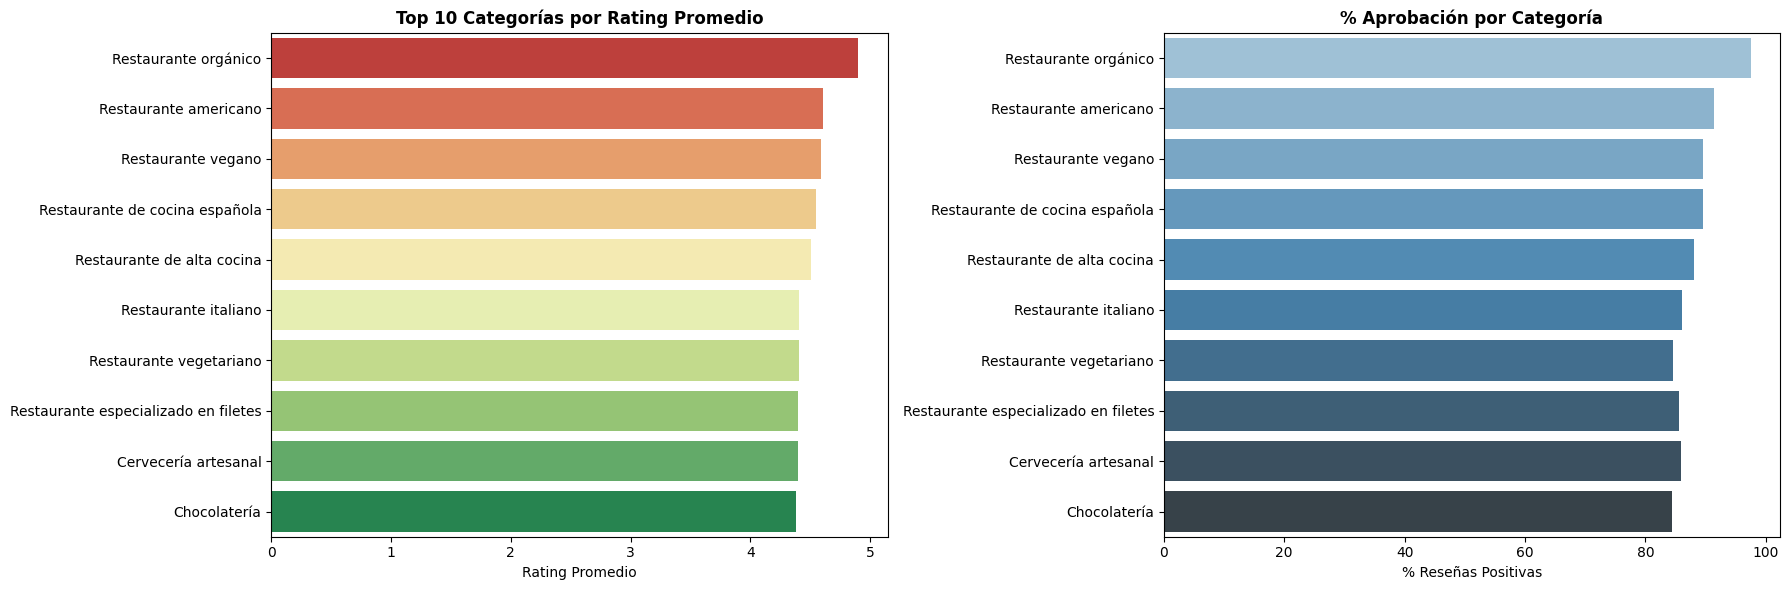

In [0]:
stats_pd = (
    spark.table(TBL_GOLD_STATS_CAT)
    .filter(F.col('total_resenas') > 500)
    .orderBy(F.desc('rating_promedio'))
    .limit(10)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax0 = sns.barplot(data=stats_pd, y='category', x='rating_promedio', palette='RdYlGn', ax=axes[0])
if ax0.get_legend(): ax0.get_legend().remove()
axes[0].set_title('Top 10 Categorías por Rating Promedio', fontweight='bold')
axes[0].set_xlabel('Rating Promedio'); axes[0].set_ylabel('')

ax1 = sns.barplot(data=stats_pd, y='category', x='porcentaje_aprobacion', palette='Blues_d', ax=axes[1])
if ax1.get_legend(): ax1.get_legend().remove()
axes[1].set_title('% Aprobación por Categoría', fontweight='bold')
axes[1].set_xlabel('% Reseñas Positivas'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()


## 5)Segmentación de Usuarios - KMeans con Spark MLlib
Refactorización: `StandardScaler` + `KMeans` + `ClusteringEvaluator` de MLlib.  

In [0]:
# Cargar features desde Gold (permanece como Spark DataFrame)
usuarios = spark.table(TBL_GOLD_FEAT_USUARIO).fillna(0)
print(f'Usuarios para clustering: {usuarios.count():,}')
usuarios.printSchema()

Usuarios para clustering: 711,324
root
 |-- username: string (nullable = true)
 |-- review_count: long (nullable = false)
 |-- avg_rating: double (nullable = false)
 |-- std_rating: double (nullable = false)
 |-- avg_word_count: double (nullable = false)
 |-- log_review_count: double (nullable = false)
 |-- log_avg_word_count: double (nullable = false)



In [0]:
# Definición del Pipeline de preprocesamiento
FEATURE_COLS = ['log_review_count', 'avg_rating', 'std_rating', 'log_avg_word_count']

assembler = VectorAssembler(inputCols=FEATURE_COLS,outputCol='features_raw',handleInvalid='skip')
scaler = StandardScaler(inputCol='features_raw',outputCol='features',withMean=True,withStd=True)

# Pipeline de preprocesamiento (sin KMeans todavía — lo añadimos en el loop)
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model= prep_pipeline.fit(usuarios)
# No tengo persist así que guardo en "cache"(tabla delta)
RUTA_CACHE_SCALED = f'{VOLUMEN_BASE}/_cache_feat_scaled'

prep_model.transform(usuarios).write.format('delta').mode('overwrite').save(RUTA_CACHE_SCALED)

df_escalado = spark.read.format('delta').load(RUTA_CACHE_SCALED)
print(f'Features escaladas: {df_escalado.count():,} filas listas')

Features escaladas: 711,324 filas listas


In [0]:
# Búsqueda del K óptimo por Silhouette
evaluator = ClusteringEvaluator(featuresCol='features',predictionCol='cluster',metricName='silhouette')
sil_scores  = {}
inertia_log = {}
print(f'  k | silhouette | inercia (WSSSE)')
print(f'----+------------+----------------')

for k in range(2, 10):
    km  = KMeans(featuresCol='features', predictionCol='cluster', k= k, seed=42, maxIter=20)
    mdl = km.fit(df_escalado)
    prd = mdl.transform(df_escalado)

    sil                = evaluator.evaluate(prd)
    inercia            = mdl.summary.trainingCost
    sil_scores[k]      = round(sil, 4)
    inertia_log[k]     = round(inercia, 2)

    print(f'  {k} |   {sil:.4f}   | {inercia:,.0f}')
    del mdl, prd

k_optimo = max(sil_scores, key=sil_scores.get)
print(f'\nK óptimo: {k_optimo}  (silhouette = {sil_scores[k_optimo]})')

  k | silhouette | inercia (WSSSE)
----+------------+----------------
  2 |   0.6335   | 1,935,717
  3 |   0.6289   | 1,405,483
  4 |   0.5564   | 1,240,034
  5 |   0.5737   | 1,040,324
  6 |   0.5012   | 778,748
  7 |   0.6442   | 590,652
  8 |   0.5783   | 638,263
  9 |   0.5732   | 507,191

K óptimo: 7  (silhouette = 0.6442)


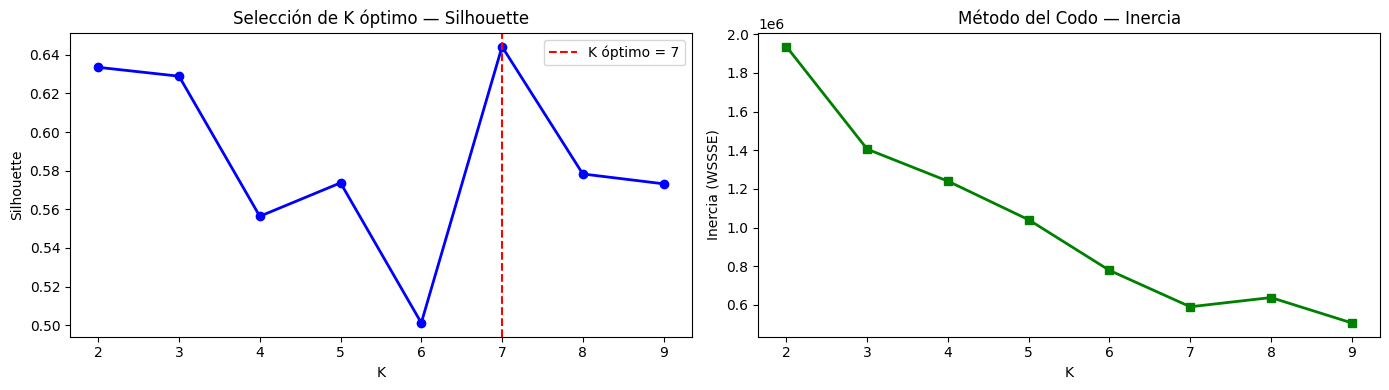

In [0]:
# Curva de silhouette y codo (inercia)
ks = list(sil_scores.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks, [sil_scores[k] for k in ks], 'bo-', linewidth=2)
axes[0].axvline(k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('Selección de K óptimo — Silhouette'); axes[0].legend()

axes[1].plot(ks, [inertia_log[k] for k in ks], 'gs-', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Inercia (WSSSE)')
axes[1].set_title('Método del Codo — Inercia')

plt.tight_layout(); plt.show()

In [0]:
# Pipeline final con K óptimo
km_final = KMeans(featuresCol='features', predictionCol='cluster', k=k_optimo, seed=42, maxIter=20)

pipeline_kmeans = Pipeline(stages=[assembler, scaler, km_final])
modelo_kmeans   = pipeline_kmeans.fit(usuarios)
sdf_clustered   = modelo_kmeans.transform(usuarios)

sil_final   = evaluator.evaluate(sdf_clustered)
inercia_fin = modelo_kmeans.stages[-1].summary.trainingCost
print(f'Silueta final (k={k_optimo}): {sil_final:.4f} /Inercia: {inercia_fin:,.0f}')

Silueta final (k=7): 0.6442 /Inercia: 590,652


In [0]:
# Perfil de clusters (agregación en Spark, sólo k filas pasan al driver)
resumen_df = (
    sdf_clustered
    .groupBy('cluster')
    .agg(
        F.count('*').alias('n_usuarios'),
        F.round(F.avg('review_count'),2).alias('resenas_promedio'),
        F.round(F.avg('avg_rating'),2).alias('rating_promedio'),
        F.round(F.avg('std_rating'),2).alias('variabilidad_rating'),
        F.round(F.avg('avg_word_count'),2).alias('palabras_promedio'),
    )
    .orderBy('cluster')
)
display(resumen_df)
resumen_pd= resumen_df.toPandas()

cluster,n_usuarios,resenas_promedio,rating_promedio,variabilidad_rating,palabras_promedio
0,71252,1.06,2.22,0.01,1.51
1,76797,3.2,4.36,0.53,4.19
2,303101,1.1,4.76,0.0,1.47
3,43033,1.08,1.57,0.02,29.87
4,29980,10.36,4.1,0.86,10.0
5,147280,1.17,4.84,0.01,18.21
6,39881,2.75,3.32,1.88,10.85


/home/spark-d23ff1cf-dd1c-4185-b304-ce/.ipykernel/23338/command-5707122455738405-1016429243:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_pd, x='cluster', y='count', palette='Spectral', ax=axes[0])


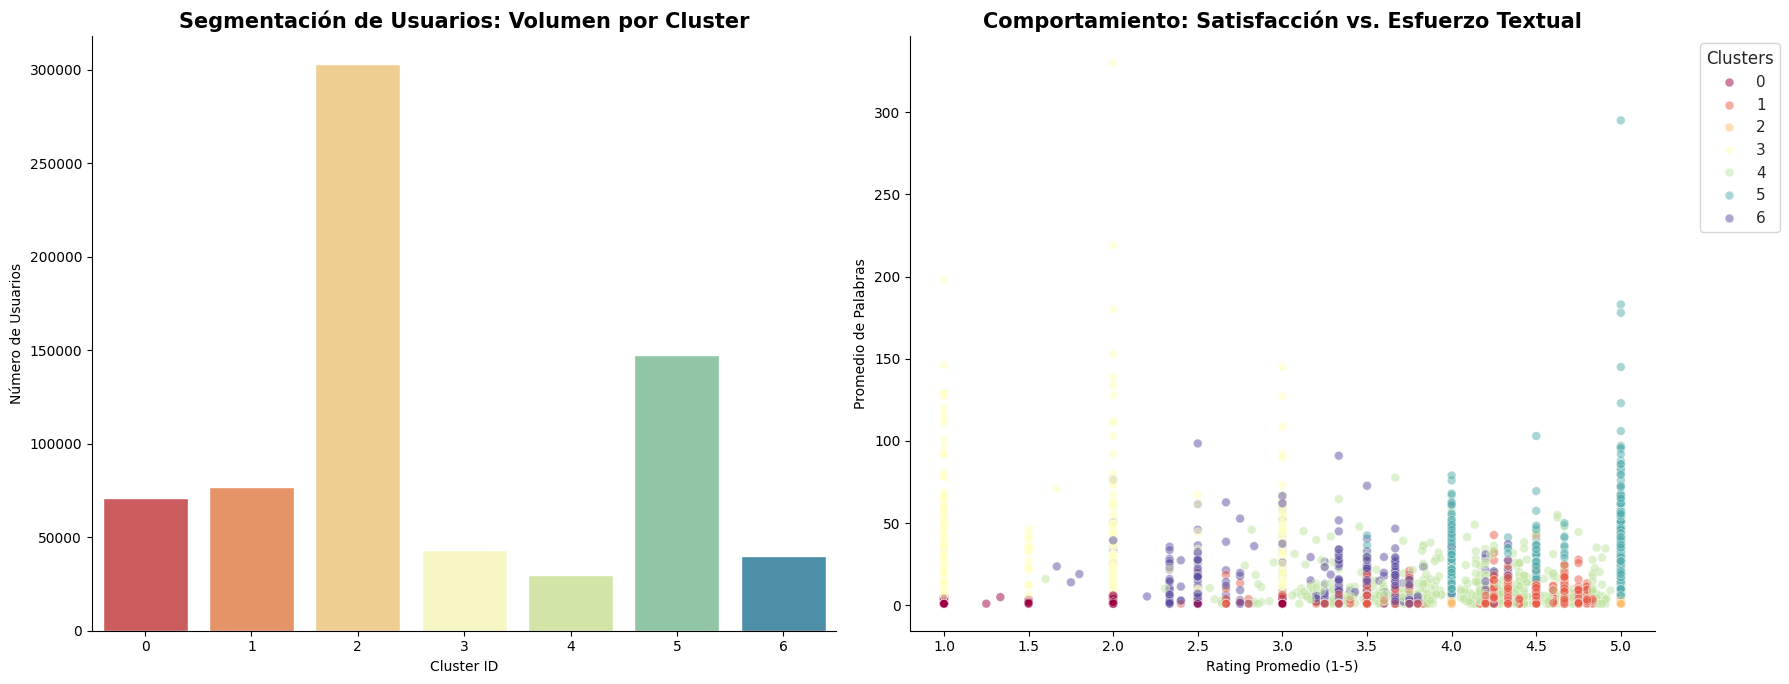

In [0]:
# Visualización: conteo por cluster + scatter sobre muestra pequeña
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style='whitegrid', palette='muted')

# Conteo (agrupado en Spark, sólo k filas al driver)
conteo_pd = sdf_clustered.groupBy('cluster').count().orderBy('cluster').toPandas()
sns.barplot(data=conteo_pd, x='cluster', y='count', palette='Spectral', ax=axes[0])
axes[0].set_title('Segmentación de Usuarios: Volumen por Cluster', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Cluster ID'); axes[0].set_ylabel('Número de Usuarios')

# Scatter - muestra de 15 000 filas para la visualización
scatter_pd = (
    sdf_clustered.select('avg_rating', 'avg_word_count', 'cluster').sample(fraction=min(15_000 / sdf_clustered.count(), 1.0), seed=42)
    .toPandas())
sns.scatterplot(data=scatter_pd, x='avg_rating', y='avg_word_count',hue='cluster', palette='Spectral', alpha=0.5, ax=axes[1], s=40,edgecolor='w')
axes[1].set_title('Comportamiento: Satisfacción vs. Esfuerzo Textual', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Rating Promedio (1-5)'); axes[1].set_ylabel('Promedio de Palabras')
axes[1].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(); plt.tight_layout(); plt.show()

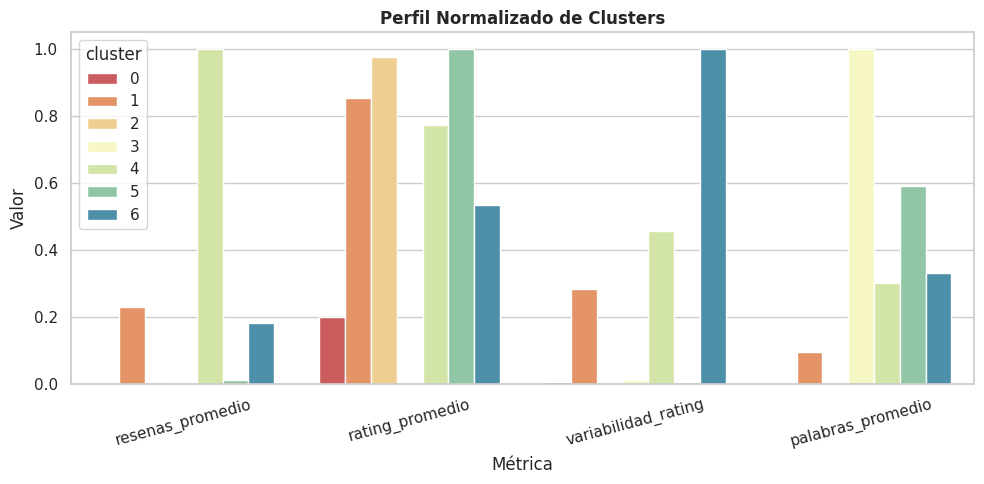

In [0]:
# Perfil normalizado de clusters
metrics = ['resenas_promedio', 'rating_promedio', 'variabilidad_rating', 'palabras_promedio']
resumen_norm = resumen_pd[metrics].copy()
resumen_norm = (resumen_norm - resumen_norm.min()) / (resumen_norm.max() - resumen_norm.min() + 1e-9)
resumen_norm['cluster'] = resumen_pd['cluster'].astype(str)
resumen_melt = resumen_norm.melt(id_vars='cluster', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resumen_melt, x='Métrica', y='Valor', hue='cluster', palette='Spectral', ax=ax)
ax.set_title('Perfil Normalizado de Clusters', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


### Resultados del Clustering

> **K óptimo seleccionado: 7** · Silhouette: **0.6442** · Inercia: **590,652**  
> Score de 0.64 indica clusters bien cohesionados. Se evaluaron k=2..9;  
> k=7 obtuvo el mayor score aunque k=2 (0.6335) y k=3 (0.6289) también  
> mostraron buena separación, lo que sugiere estructura jerárquica en los datos.

### Interpretación de Clusters

| Cluster | N° Usuarios | Perfil | Descripción | Acción recomendada |
|---------|-------------|--------|-------------|-------------------|
| 0 | 71,252 | Decepcionado silencioso | Una sola visita, rating muy bajo (2.22), texto mínimo — no volvió | Campaña de recuperación: descuento en segunda visita, encuesta de causa |
| 1 | 76,797 | Recurrente satisfecho | 3 reseñas promedio, rating bueno (4.36), engagement moderado | Mantener experiencia — candidato a programa de puntos |
| 2 | 303,101 | Validador masivo | Grupo más grande, rating casi perfecto (4.76) pero texto mínimo y sin variabilidad — posible reseña incentivada | Analizar autenticidad; si es orgánico, explotar como NPS positivo |
| 3 | 43,033 | Crítico detallista | Rating muy bajo (1.57), textos largos (30 palabras) — escribe para quejarse | Prioridad operacional: escalar quejas a gestión de restaurantes |
| 4 | 29,980 | Foodie activo | Usuario más frecuente (10 reseñas), rating equilibrado (4.10), alta variabilidad — tiene criterio propio | Programa de embajadores / influencer gastronómico |
| 5 | 147,280 | Promotor genuino | Rating casi perfecto (4.84), textos elaborados (18 palabras) — recomienda con detalle | Incentivar reseñas en Google Maps y redes sociales |
| 6 | 39,881 | Experiencia errática | Rating medio (3.32) con altísima variabilidad (1.88) — sus visitas son muy dispares entre sí | Investigar consistencia del servicio en los locales que frecuenta |

## 6)Pipeline NLP - TF-IDF con Spark MLlib
 **Refactorización:** `Tokenizer` + `StopWordsRemover` + `CountVectorizer` + `IDF` nativos de Spark.  
 Reemplaza `TfidfVectorizer` de scikit-learn y `nltk`


In [0]:
# Stopwords en español (hardcoded para no depender de nltk en Databricks Serverless)
SPANISH_STOPS = [
    'de','la','que','el','en','y','a','los','del','se','las','por','un','para',
    'con','no','una','su','al','lo','como','más','pero','sus','le','ya','o',
    'este','sí','porque','esta','entre','cuando','muy','sin','sobre','también',
    'me','hasta','hay','donde','quien','desde','todo','nos','durante','todos',
    'uno','les','ni','contra','otros','ese','eso','ante','ellos','e','esto',
    'mí','antes','algunos','qué','unos','yo','otro','otras','otra','él','tanto',
    'esa','estos','mucho','quienes','nada','muchos','cual','poco','ella','estar',
    'estas','algunas','algo','nosotros','mi','mis','tú','te','ti','tu','tus',
    'ellas','nos','vosotros','vosotras','os','mío','mía','míos','mías','tuyo',
    # Stopwords de dominio gastronómico
    'si','lugar','sitio','vez','mas','ser','hacer','ir','muy','bien','todo',
    'nada','así','aquí','café','restaurante','local','comida','lima','peru',
]


In [0]:
# Selección del corpus . filtro y muestreo en Spark (no .toPandas() aquí)
sdf_nlp = (
    df.select('id_review', 'caption_clean', 'sentimiento').filter(F.col('caption_clean').isNotNull() & (F.length('caption_clean') > 20))
    .sample(fraction=0.15, seed=42)   # ~180 K reseñas del total
)
print(f'Reseñas para NLP: {sdf_nlp.count():,}')

Reseñas para NLP: 77,127


In [0]:
# Pipeline NLP completo en Spark
tokenizer = Tokenizer(inputCol='caption_clean', outputCol='tokens_raw')
remover = StopWordsRemover(inputCol='tokens_raw',outputCol='tokens',stopWords=SPANISH_STOPS,caseSensitive=False)

cv = CountVectorizer(
    inputCol='tokens',
    outputCol='tf_vector',
    maxDF=0.85,
    minDF=5.0, # mínimo 5 documentos - equivalente a min_df=5 de sklearn
    vocabSize=10_000
)

idf = IDF(inputCol='tf_vector',outputCol='tfidf_vector',minDocFreq=5)

pipeline_nlp = Pipeline(stages=[tokenizer, remover, cv, idf])
modelo_nlp= pipeline_nlp.fit(sdf_nlp)
sdf_tfidf = modelo_nlp.transform(sdf_nlp)

print('Pipeline NLP entrenado')
print(f'Vocabulario real aprendido: {len(modelo_nlp.stages[2].vocabulary)}')
sdf_tfidf.select('id_review', 'tokens', 'tfidf_vector').show(5, truncate=80)

Pipeline NLP entrenado
Vocabulario real aprendido: 8663
+--------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                           id_review|                                                                          tokens|                                                                    tfidf_vector|
+--------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                 ChZDSUhNMG9nS0VJQ0FnSURSNWZEYWNBEAE|                               [recomendable, , bueno, puede, comer, ahí, mismo]|(8663,[3,15,24,39,98,229,257],[2.0550550872997424,2.8764406206447237,3.255894...|
|Ci9DQUlRQUN

## 7)Modelado de Tópicos - LDA con Spark MLlib
 Refactorización: `LDA` de `pyspark.ml.clustering` reemplaza a `LatentDirichletAllocation` de sklearn.  


In [0]:
# LDA usa el vector de conteos (tf_vector), no el TF-IDF
# Obtenemos el vocabulario del CountVectorizerModel (stages[2])
vocab = modelo_nlp.stages[2].vocabulary   # lista Python — sólo el vocab, no los datos

lda = LDA(
    featuresCol='tf_vector',
    k=5,# número de tópicos
    maxIter=10,
    optimizer='online',
    seed=42
)

modelo_lda  = lda.fit(sdf_tfidf)

# Perplejidad (lower is better) y log-verosimilitud
loglik   = modelo_lda.logLikelihood(sdf_tfidf)
logperp  = modelo_lda.logPerplexity(sdf_tfidf)
print(f'Log-Verosimilitud : {loglik:.2f}')
print(f'Log-Perplejidad   : {logperp:.4f}  (cuanto menor, mejor)')

Log-Verosimilitud : -5515194.73
Log-Perplejidad   : 7.3551  (cuanto menor, mejor)


In [0]:
# Inspección de tópicos
# topicsMatrix() → DataFrame Spark con distribución de términos por tópico
topics_df = modelo_lda.describeTopics(maxTermsPerTopic=10)

for row in topics_df.collect():
    top_words = [vocab[i] for i in row['termIndices']]
    print(f"Tópico {row['topic']}: {' | '.join(top_words)}")

Tópico 0: pollo | es | atención | pésima | mala | son | rico | agradable | sabor | falta
Tópico 1: es |  | buen | buena | atención | servicio | platos | estaba | sabor | son
Tópico 2: excelente | atención | buena | servicio | ambiente | buen | agradable | amable | acogedor | platos
Tópico 3: mejor | buena | es | atención | buen | pizzas | buenas | mejores | familia | he
Tópico 4: buena | atención | es | pollo | rico | sabor | agradable | buen | rica | papas


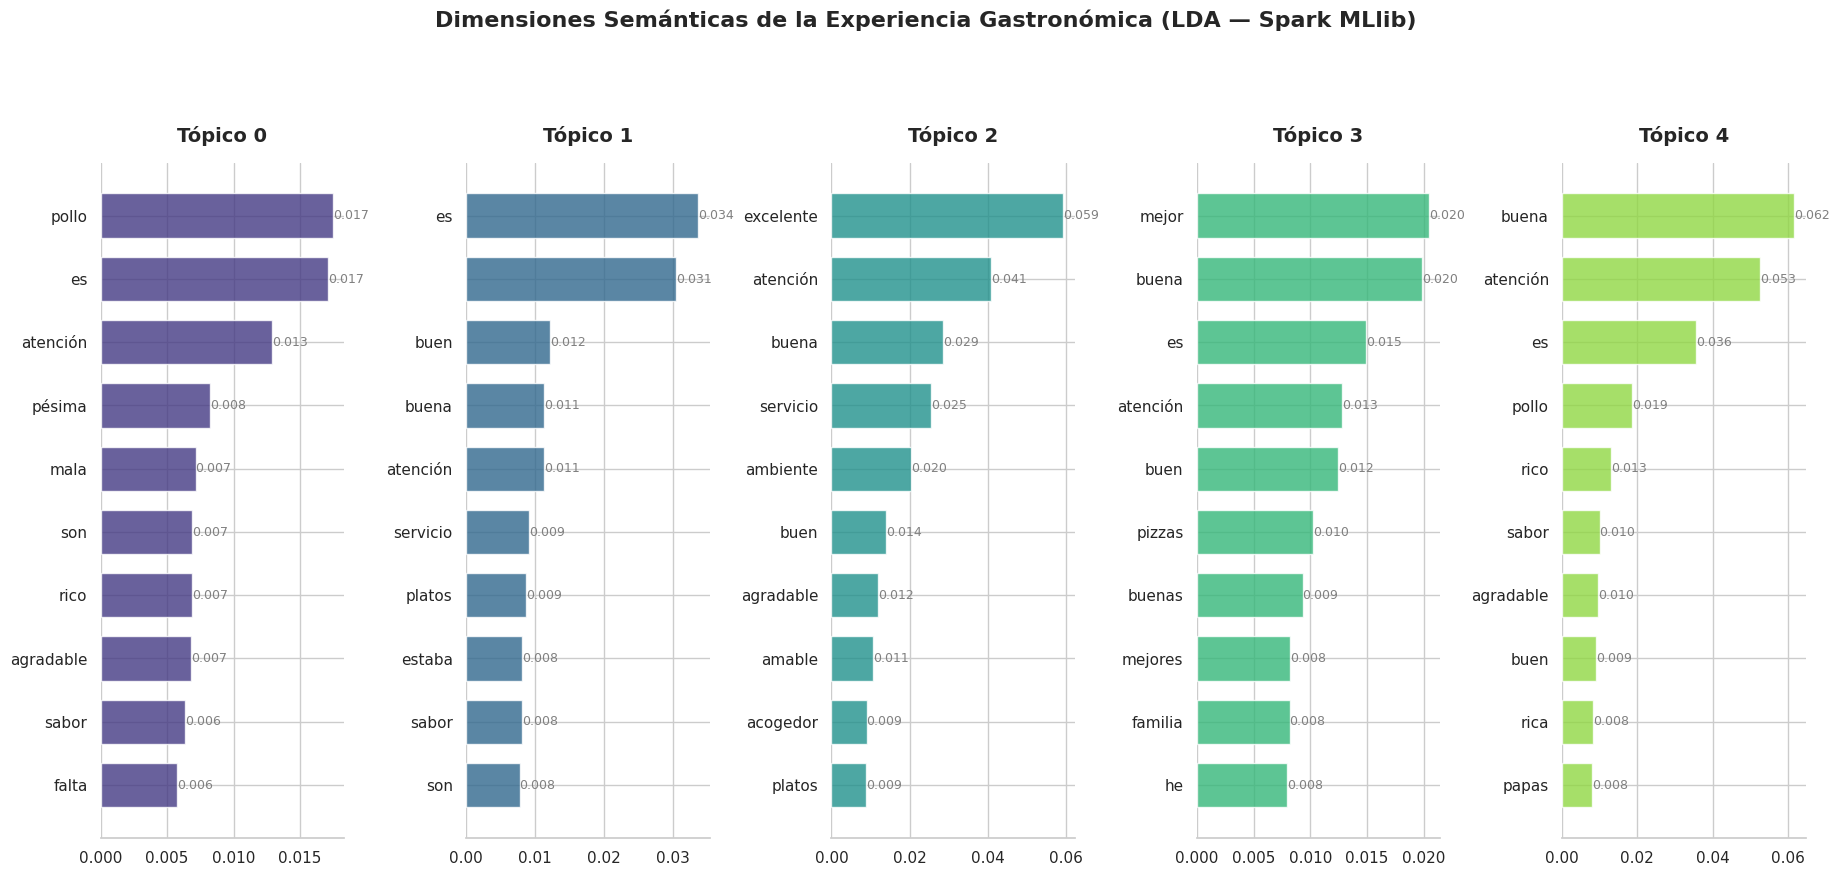

In [0]:
# Visualización de tópicos
topics_pd = topics_df.toPandas()   # sólo 5 filas × 10 términos — trivial

fig, axes = plt.subplots(1, 5, figsize=(22, 9), sharey=False)
palette = sns.color_palette('viridis', 5)

for _, row in topics_pd.iterrows():
    idx        = int(row['topic'])
    top_words  = [vocab[i]       for i in row['termIndices']]
    weights    = [row['termWeights'][j] for j in range(len(row['termIndices']))]
    ax         = axes[idx]

    bars = ax.barh(top_words, weights, height=0.7, color=palette[idx], alpha=0.8)
    ax.set_title(f'Tópico {idx}', fontdict={'fontsize': 14, 'fontweight': 'bold'}, pad=15)
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='major', labelsize=11)

    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height() / 2,f'{width:.3f}', va='center', ha='left', fontsize=9, color='gray')

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Dimensiones Semánticas de la Experiencia Gastronómica (LDA — Spark MLlib)',fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.5)
plt.show()

In [0]:
# Asignación de tópico dominante por reseña (también en Spark)
sdf_topics = modelo_lda.transform(sdf_tfidf)   # añade columna 'topicDistribution'

# Tópico con mayor probabilidad
@F.udf(returnType='int')
def argmax_udf(v):
    arr = v.toArray()
    return int(arr.argmax())

sdf_topics = sdf_topics.withColumn('topico_dominante', argmax_udf(F.col('topicDistribution')))
# Distribución de reseñas por tópico dominante
display(sdf_topics.groupBy('topico_dominante').count().orderBy('topico_dominante'))

topico_dominante,count
0,6268
1,31082
2,19280
3,7152
4,13345


## 8)Pipeline Unificado - KMeans integrado en un solo objeto Pipeline
encadenar **todo** (preprocesamiento + KMeans) en un solo `Pipeline`  
de Spark que se puede guardar y reaplicar con `modelo.transform()`.


In [0]:
# Pipeline unificado: VectorAssembler → StandardScaler → KMeans
assembler_u = VectorAssembler(inputCols=FEATURE_COLS,outputCol='features_raw',handleInvalid='skip')
scaler_u = StandardScaler(inputCol='features_raw',outputCol='features',withMean=True, withStd=True)
kmeans_u = KMeans(featuresCol='features',predictionCol='cluster',k=k_optimo,seed=42,maxIter=20)

pipeline_final  = Pipeline(stages=[assembler_u, scaler_u, kmeans_u])
modelo_final    = pipeline_final.fit(usuarios)
sdf_resultado   = modelo_final.transform(usuarios)

# Evaluación
sil_u = ClusteringEvaluator(featuresCol='features', predictionCol='cluster').evaluate(sdf_resultado)
print(f'Pipeline unificado - Silhouette: {sil_u:.4f}')
display(sdf_resultado.select(*FEATURE_COLS, 'cluster').limit(10))

Pipeline unificado - Silhouette: 0.6442


log_review_count,avg_rating,std_rating,log_avg_word_count,cluster
0.6931,5.0,0.0,0.6931,2
0.6931,5.0,0.0,2.9444,5
0.6931,5.0,0.0,0.6931,2
1.0986,5.0,0.0,0.6931,2
0.6931,5.0,0.0,0.6931,2
3.4657,3.9032,1.1062,2.2731,4
0.6931,5.0,0.0,3.5264,5
1.3863,5.0,0.0,1.7346,1
0.6931,5.0,0.0,0.6931,2
1.7918,3.6,0.5477,1.8563,1


In [0]:
RUTA_MODELO_KMEANS = f'{VOLUMEN_BASE}/modelo_kmeans_usuarios'
modelo_final.write().overwrite().save(RUTA_MODELO_KMEANS)
print(f'Modelo guardado en: {RUTA_MODELO_KMEANS}')

Modelo guardado en: /Volumes/proyecto_bda/bda_schema/bda_volumen/modelo_kmeans_usuarios


In [0]:
# Guardar pipeline NLP + LDA en volumen
RUTA_MODELO_NLP = f'{VOLUMEN_BASE}/modelo_nlp_tfidf'
RUTA_MODELO_LDA = f'{VOLUMEN_BASE}/modelo_lda'

modelo_nlp.write().overwrite().save(RUTA_MODELO_NLP)
modelo_lda.write().overwrite().save(RUTA_MODELO_LDA)
print(f'Modelos NLP/LDA guardados.')

Modelos NLP/LDA guardados.


## Resumen — Componentes Spark MLlib utilizados

| Paso | Clase MLlib | Reemplaza a |
|------|-------------|-------------|
| Ensamblado de features | `VectorAssembler` | `np.array` / columnas pandas |
| Escalado | `StandardScaler` | `sklearn.preprocessing.StandardScaler` |
| Clustering | `KMeans` (MLlib) | `sklearn.cluster.KMeans` |
| Evaluación clustering | `ClusteringEvaluator` | `sklearn.metrics.silhouette_score` |
| Tokenización | `Tokenizer` | `str.split` / `nltk.word_tokenize` |
| Eliminación stopwords | `StopWordsRemover` | stopwords de `nltk` |
| Vectorización TF | `CountVectorizer` | `sklearn.feature_extraction.text.CountVectorizer` |
| Ponderación TF-IDF | `IDF` | `sklearn.feature_extraction.text.TfidfVectorizer` |
| Modelado de tópicos | `LDA` (MLlib) | `sklearn.decomposition.LatentDirichletAllocation` |
| Orquestación | `Pipeline` (MLlib) | scripts secuenciales |

> **Beneficio:** ningún `collect()` / `.toPandas()` sobre el dataset completo.  
> Los +1.2 M registros se procesan en el cluster de forma distribuida.
